# 1. Data Ingestion & Preprocessing

Load XES event log and convert to standardized DataFrames.

## 1.0 Install Dependencies

In [1]:
# Install required packages (safe to re-run; --quiet suppresses noise)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'pandas',
    'pyarrow',
    'numpy',
    'matplotlib',
    'seaborn'
])


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: /mnt/hdd/Code/Git/bwa/.venv/bin/python -m pip install --upgrade pip


0

## 1.1 Setup

In [2]:
# Colab setup - uncomment if needed
# from google.colab import drive
# drive.mount('/content/drive')
import sys
from pathlib import Path
# Walk up from cwd until we find the src/ directory, so this works
# whether the kernel starts in the repo root or the notebooks/ folder.
_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / 'src' / 'data_ingestion.py').exists():
        _repo_root = _p
        _src = str(_p / 'src')
        if _src not in sys.path:
            sys.path.insert(0, _src)
        break
from data_ingestion import parse_xes
from dataset_registry import get_config, apply_subprocess_filter

## 1.2 Configuration

In [3]:
# Set to 'BPIC2012' for the full log
# (W subprocess = W_ activities, COMPLETE lifecycle — directly comparable to RIMS_DRL)
DATASET = "BPIC2012"
OUTPUT_DIR = _repo_root / 'output' / DATASET
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
config = get_config(DATASET)
print(f"Dataset: {config.name}")
if config.subprocess_filter:
    print(f"Subprocess filter: {config.subprocess_filter}")
print(f"Domain: {config.domain}")

Dataset: BPIC2012
Domain: loan


## 1.3 Load XES

In [4]:
import pandas as pd
print("Loading XES...")

if config.municipality_files:
    # Multi-municipality dataset (e.g. BPIC2015): load each file separately,
    # tag rows with their municipality, and prefix case_ids to avoid collisions
    # (the 5 BPIC2015 XES files share case ID namespaces).
    _muni_dfs = []
    for tag, xes_file in config.municipality_files.items():
        _mdf = parse_xes(xes_file)
        _mdf['municipality'] = tag
        _mdf['case_id'] = tag + '_' + _mdf['case_id'].astype(str)
        _muni_dfs.append(_mdf)
    df = pd.concat(_muni_dfs, ignore_index=True)
    df = apply_subprocess_filter(df, config)
    print(f'Municipality distribution:')
    print(df.groupby('municipality')['case_id'].nunique().to_string())
else:
    # Single-file or subprocess-filtered dataset
    dfs = []
    for xes_file in config.files:
        dfs.append(parse_xes(xes_file))
    df = pd.concat(dfs, ignore_index=True)
    df = apply_subprocess_filter(df, config)

print(f"Loaded {len(df)} events, {df['case_id'].nunique()} cases")

Loading XES...


Loaded 262200 events, 13087 cases


## 1.4 Export

In [5]:
import json
train_file = OUTPUT_DIR / f'events_{DATASET}_train.parquet'
df.to_parquet(train_file, engine='pyarrow', index=False)
print(f"Saved: {train_file}")
session_config = {
    "dataset_name": DATASET,
    "domain": config.domain,
    "train_cases": int(df["case_id"].nunique())
}
with open(OUTPUT_DIR / 'session_config.json', 'w') as f:
    json.dump(session_config, f, indent=2)

Saved: /mnt/hdd/Code/Git/bwa/output/BPIC2012/events_BPIC2012_train.parquet


## 1.5 Data Visualization

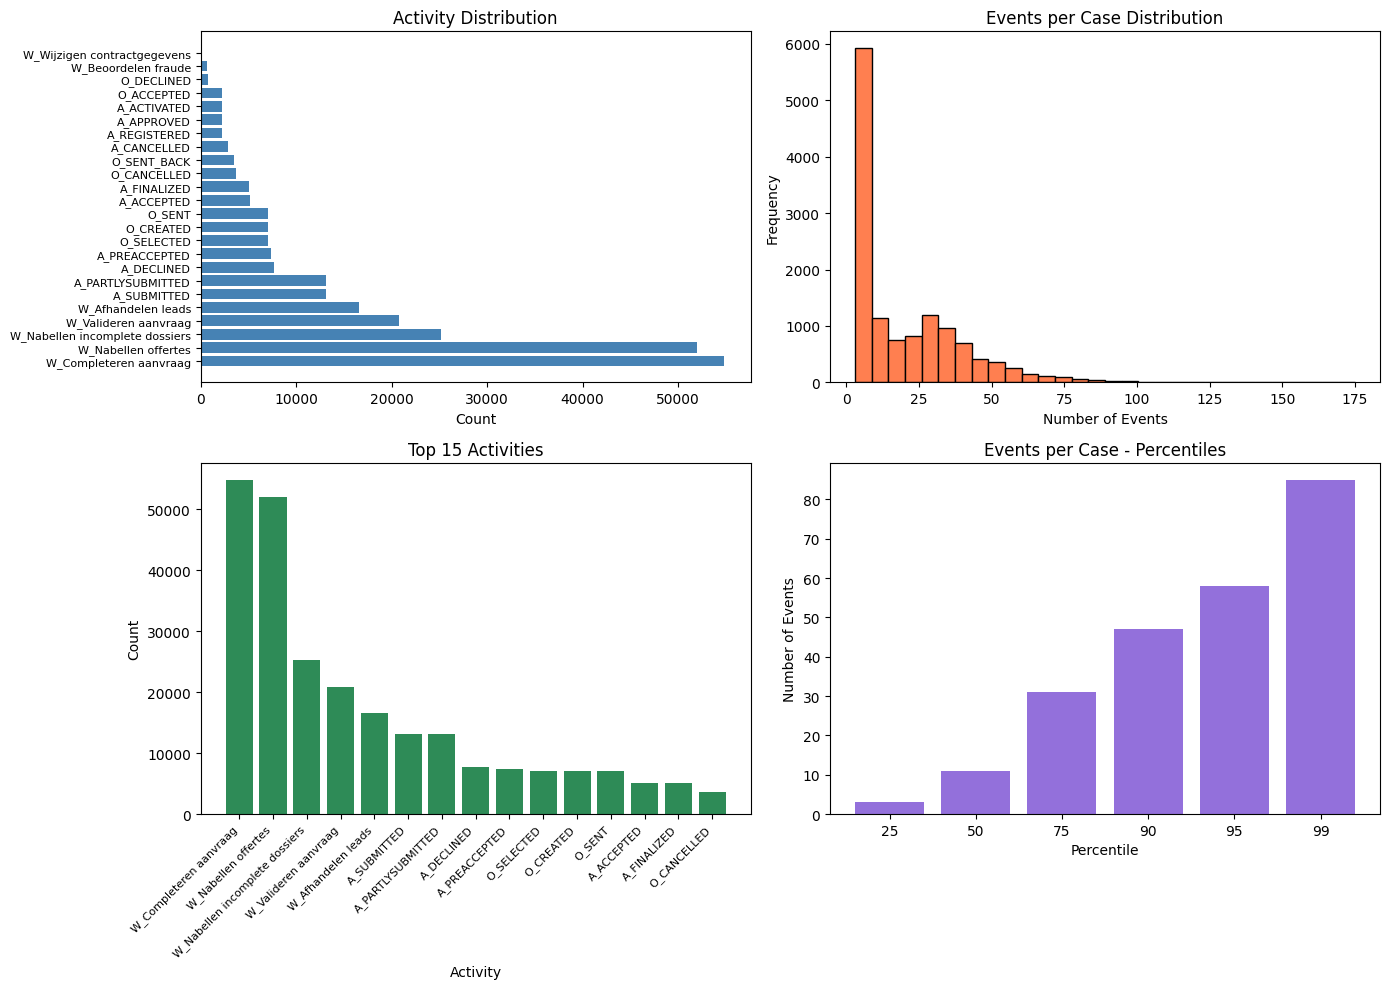

Saved visualization to /mnt/hdd/Code/Git/bwa/output/BPIC2012/data_overview.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
activity_counts = df['activity'].value_counts()
axes[0, 0].barh(activity_counts.index, activity_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Activity Distribution')
axes[0, 0].tick_params(axis='y', labelsize=8)
events_per_case = df.groupby('case_id').size()
axes[0, 1].hist(events_per_case, bins=30, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Number of Events')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Events per Case Distribution')
axes[1, 0].bar(range(len(activity_counts.head(15))), activity_counts.head(15).values, color='seagreen')
axes[1, 0].set_xticks(range(len(activity_counts.head(15))))
axes[1, 0].set_xticklabels(activity_counts.head(15).index, rotation=45, ha='right', fontsize=8)
axes[1, 0].set_xlabel('Activity')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Top 15 Activities')
percentiles = [25, 50, 75, 90, 95, 99]
percentile_values = [events_per_case.quantile(p/100) for p in percentiles]
axes[1, 1].bar([str(p) for p in percentiles], percentile_values, color='mediumpurple')
axes[1, 1].set_xlabel('Percentile')
axes[1, 1].set_ylabel('Number of Events')
axes[1, 1].set_title('Events per Case - Percentiles')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved visualization to {OUTPUT_DIR / 'data_overview.png'}")